# Beli Voice-of-Customer Analysis — Exploration

Surfacing and prioritizing product pain points from ~825 public app reviews
(Apple App Store + Google Play) for the restaurant-ranking app Beli.

**Note on the first cell:** the two `os.environ` lines are set *before* importing
sklearn to prevent an OpenMP library conflict that was crashing the kernel on this
Mac/conda setup. `OMP_NUM_THREADS=1` disables the threading that triggered it.
Embeddings are reloaded from disk so I don't have to re-run the (slower) embedding
step every session.

I load each source separately and drop duplicate rows before combining. Quick
gut-check: I look at the mean rating per source to see whether the two platforms
skew differently before merging them — a sanity check, not a finding.

Two sources, same schema by design, so they stack cleanly with `pd.concat`. The
combined corpus is written to `combined_reviews.csv` as the single file the rest
of the analysis reads from.

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import numpy as np
embeddings = np.load("data/embeddings.npy")  
print(embeddings.shape)

(825, 384)


In [2]:
from sklearn.cluster import KMeans
km = KMeans(n_clusters=3, random_state=42, n_init=5)
km.fit(embeddings)
print("survived:", km.inertia_)

survived: 493.8096618652344


In [3]:
import pandas as pd

In [4]:
google_play = pd.read_csv('data/google_play_reviews.csv')
google_play = google_play.drop_duplicates()
google_play

,source,text,rating,version,date,title,storefront,author,review_id
0,google_play,Love the concept but the app is almost unusabl...,2,9.3.1,2026-06-21 09:32:35,NaN,us,Ben Varquez,0
1,google_play,Blocks the most useful features and requires y...,1,9.3.1,2026-06-20 17:25:18,NaN,us,Eric Zhang,1
2,google_play,the popups on the top of the front page make i...,4,9.1.2,2026-06-11 14:16:29,NaN,us,Jacob Maez,2
3,google_play,"Start by asking your number, warning that you'...",1,NaN,2026-06-09 04:19:00,NaN,us,Marie Euzen,3
4,google_play,"Great app, but I absolutely hate that so many ...",2,9.0.8,2026-06-01 10:12:56,NaN,us,Rohini Pillai,4
...,...,...,...,...,...,...,...,...,...
258,google_play,Love it so far. Just wish there was a way to r...,4,2.3.7,2022-12-09 00:08:40,NaN,us,Kim Yuenmak,258
259,google_play,Ridiculously buggy app. Unusable and will defi...,1,2.0.13,2022-11-18 11:06:26,NaN,us,Cameron Dixon,259
260,google_play,I've never felt inclined to write a public app...,5,2.0.13,2022-11-02 14:23:31,NaN,us,Emily Ginsburg,260
261,google_play,From insta,5,NaN,2022-10-29 21:06:53,NaN,us,Lucas F,261


In [5]:
app_store = pd.read_csv('data/app_store_reviews.csv')
app_store = app_store.drop_duplicates()
app_store

,source,text,rating,version,date,title,storefront,author,review_id
0,app_store,"PLEASE bring back the old smaller pictures, th...",1,9.3.1,NaN,NEW UI SUCKS,us,wsonja112,0
1,app_store,The UI is clunky and requiring invites to use ...,1,9.3.1,NaN,Poor design and scammy behavior,us,scknight4,1
2,app_store,It is good at what it does and it’s free nd no...,5,9.3.1,NaN,Happy,us,Gstarbanana,2
3,app_store,I have to share that I am drifting away from t...,2,9.3.1,NaN,Worse than Google Maps,us,brenda y. g.,3
4,app_store,All I want to do is find a restaurant near my ...,1,9.3.0,NaN,Useless,us,DestructoTex,4
...,...,...,...,...,...,...,...,...,...
557,app_store,If only I had enough money to go everywhere,5,2.5.3,NaN,This app has changed my life,ca,Stormgirl77,557
558,app_store,Thought it was a way to rate restaurants and k...,2,9.0.8,NaN,Food social media?,au,Just another social app,558
559,app_store,If you live somewhere that has two cities loca...,3,8.2.18,NaN,Missing feature,au,nuttcase13,559
560,app_store,App has great potential but devs don’t add any...,4,8.2.11,NaN,Devs do not listen to feedback,au,Tommgau,560


In [6]:
app_store['rating'].mean()

np.float64(3.412811387900356)

In [7]:
google_play['rating'].mean()

np.float64(3.106463878326996)

### Final cleaning 

After combining, I drop any rows with no review text (nothing to analyze) and
normalize the `date` column to a real datetime so it's sortable for later
version/time work. Apple rows have no date (the RSS feed doesn't provide one),
so those stay null by design — the time-based analysis leans on Google Play,
which attaches both a date and an app version to every review.

In [8]:
result = pd.concat([app_store, google_play], ignore_index=True)
print(result)
print(len(result)) 
result.to_csv("data/combined_reviews.csv", index=False)

          source                                               text  rating  \
0      app_store  PLEASE bring back the old smaller pictures, th...       1   
1      app_store  The UI is clunky and requiring invites to use ...       1   
2      app_store  It is good at what it does and it’s free nd no...       5   
3      app_store  I have to share that I am drifting away from t...       2   
4      app_store  All I want to do is find a restaurant near my ...       1   
..           ...                                                ...     ...   
820  google_play  Love it so far. Just wish there was a way to r...       4   
821  google_play  Ridiculously buggy app. Unusable and will defi...       1   
822  google_play  I've never felt inclined to write a public app...       5   
823  google_play                                         From insta       5   
824  google_play  I like the concept but the app is laggy and ke...       3   

    version                 date                   

In [9]:
combined = pd.read_csv('data/combined_reviews.csv')
combined = combined.dropna(subset=['text'])
combined["date"] = pd.to_datetime(combined["date"])
combined

,source,text,rating,version,date,title,storefront,author,review_id
0,app_store,"PLEASE bring back the old smaller pictures, th...",1,9.3.1,NaT,NEW UI SUCKS,us,wsonja112,0
1,app_store,The UI is clunky and requiring invites to use ...,1,9.3.1,NaT,Poor design and scammy behavior,us,scknight4,1
2,app_store,It is good at what it does and it’s free nd no...,5,9.3.1,NaT,Happy,us,Gstarbanana,2
3,app_store,I have to share that I am drifting away from t...,2,9.3.1,NaT,Worse than Google Maps,us,brenda y. g.,3
4,app_store,All I want to do is find a restaurant near my ...,1,9.3.0,NaT,Useless,us,DestructoTex,4
...,...,...,...,...,...,...,...,...,...
820,google_play,Love it so far. Just wish there was a way to r...,4,2.3.7,2022-12-09 00:08:40,NaN,us,Kim Yuenmak,258
821,google_play,Ridiculously buggy app. Unusable and will defi...,1,2.0.13,2022-11-18 11:06:26,NaN,us,Cameron Dixon,259
822,google_play,I've never felt inclined to write a public app...,5,2.0.13,2022-11-02 14:23:31,NaN,us,Emily Ginsburg,260
823,google_play,From insta,5,NaN,2022-10-29 21:06:53,NaN,us,Lucas F,261


## Theme extraction: embedding the reviews

### What a sentence transformer does
A sentence transformer converts each review into a vector — a list of ~384 numbers
that represents the text's *meaning*. The defining property: texts with similar
meaning land close together in that number-space, even when they share no words.
So "the ranking system is confusing" and "I can't figure out how the rating works"
end up near each other despite using completely different vocabulary. Once every
review is a vector, "find the themes" becomes "find groups of nearby vectors" — a
problem clustering can solve.

### Why this method is a good fit here
- **It captures meaning, not just keywords.** Reviewers describe the same issue
  countless ways — typos, slang, abbreviations, different phrasings. A keyword or
  word-count approach would file "invite 4 friends," "forced to recommend it," and
  "harass others into joining" as three unrelated things; embeddings recognize them
  as one theme. For messy user-generated text, that semantic grouping is the whole
  point.
- **The themes aren't known in advance.** My first research question is literally
  "what do users talk about?" Embeddings let themes *emerge* from the data instead
  of forcing me to pre-specify a keyword list — which would bias the result toward
  what I already expected to find.
- **It's a pretrained, off-the-shelf model — no training required.** I'm using the
  model only to *represent* text, not training or fine-tuning anything. That keeps
  the pipeline simple, reproducible, free, and fully offline.
- **It's the right scale.** 825 short reviews embed in seconds, with no memory or
  cost constraints.

### Model choice
I used `all-MiniLM-L6-v2`: small, fast, 384-dimensional, and strong on short text
like reviews. Larger models exist but add little at this scale.

In [10]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer("all-MiniLM-L6-v2")
reviews = combined["text"].tolist()
embeddings = model.encode(reviews, show_progress_bar=True)
print(embeddings.shape) 

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/26 [00:00<?, ?it/s]

(825, 384)


In [11]:
import numpy as np
np.save("data/embeddings.npy", embeddings)

## Clustering the embeddings into themes

### What KMeans does
KMeans groups the 825 review-vectors into *k* clusters by repeating two steps until
they stabilize: assign each point to its nearest cluster center, then move each
center to the average of its assigned points. When the centers stop moving, every
review belongs to the cluster it's closest to. The themes are then read off by
inspecting what's in each cluster.

### Why KMeans (and why not the alternatives)
- **vs. BERTopic / HDBSCAN:** I considered BERTopic, but it's built for large
  corpora and its HDBSCAN clustering strands uncertain points in an "outlier"
  bucket — on a small set like mine, that can leave a large share of reviews
  unclustered. KMeans assigns *every* review to a cluster, which suits 825 reviews
  far better.
- **It's transparent and reproducible.** Two understandable steps (embed, then
  cluster), and with a fixed `random_state` the results are stable run to run. For
  a portfolio project I need to *explain and defend* every step, and KMeans is
  simple enough to do that fully.
- **The "manual" parts are a feature, not a weakness.** KMeans makes me choose *k*
  and name the clusters myself — and that human reading *is* the analytical
  judgment and the validation step, not busywork the algorithm should have done.

### How I chose k
KMeans needs *k* specified up front, so I used the elbow method: fit across a range
of *k*, plot the inertia (total distance from points to their centers), and look
for the bend where added clusters stop helping much. The elbow was soft rather than
sharp, so I treated it as a range and picked the *k* whose clusters read as the most
coherent themes (k=8), checking that cluster sizes were reasonably balanced rather
than one dominant catch-all.

### What clustering told me — and its limit
Several clusters were crisp (map/navigation, the forced-invite wall, positive/diary
use), but others were muddy: the same complaints, especially the invite wall, bled
across multiple clusters. That bleed is itself a finding (the invite wall clearly
dominates), but it also exposes the core limitation — **a single review often spans
several themes, yet KMeans forces it into exactly one cluster.** That's what
motivated moving to multi-label tagging for the actual theme assignment, while
keeping clustering for what it did well: discovering the taxonomy.

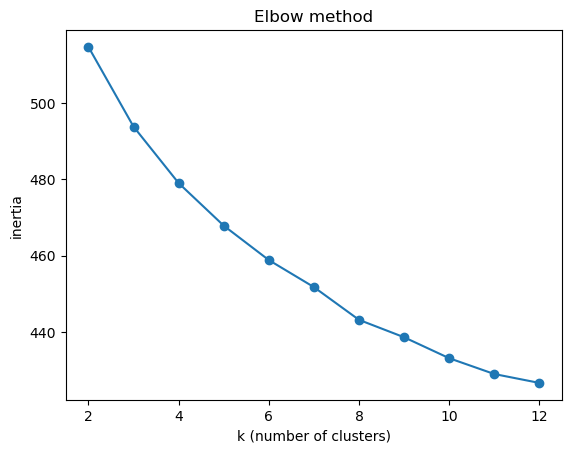

In [12]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
K_range = range(2, 13) 

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(embeddings)
    inertias.append(km.inertia_)

plt.plot(K_range, inertias, marker="o")
plt.xlabel("k (number of clusters)")
plt.ylabel("inertia")
plt.title("Elbow method")
plt.show()

In [13]:
k = 8  

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
combined["cluster"] = kmeans.fit_predict(embeddings)


print(combined["cluster"].value_counts().sort_index())

cluster
0    102
1    150
2    108
3    128
4    119
5     91
6     62
7     65
Name: count, dtype: int64


In [14]:
for c in range(8):
    subset = combined[combined["cluster"] == c]
    print(f"\n{'='*60}\nCLUSTER {c}  (n={len(subset)})\n{'='*60}")
    for s in subset["text"].head(8):
        print(" •", str(s)[:160])


CLUSTER 0  (n=102)
 • PLEASE bring back the old smaller pictures, the new pictures are too big, and why is there no tagged post feature!!!!!
 • It is good at what it does and it’s free nd not
Adds
 • I love being able to log all the restraunts I’ve tired and tag my friends it’s like a little diary of all the places I’ve gone and people I’ve eaten with
 • It’s a poor experience if you don’t want to give them all of your data. It feels invasive and coercive.
 • Tastefully entertaining! :)
 • super fun & allows you to be specific
 • Every update is allegedly a UX update but still yet no dark mode or back gesture. PLEASE!
 • I have all notifications turned off but they still insist on sending me notifications.

CLUSTER 1  (n=150)
 • The UI is clunky and requiring invites to use certain features is scammy. 

It would be better if you could more easily search recommendations in a certain area
 • All I want to do is find a restaurant near my hotel. And I have to invite 4 people to use the ap

## Multi-label theme + sentiment tagging

Clustering surfaced the candidate taxonomy but showed that reviews are
multi-thematic. To respect that, I switched the *assignment* method: instead of
forcing each review into one cluster, I tag each review against the derived theme
list and allow **multiple themes per review**, each with its own sentiment.

I used a small, cheap classification model (Claude Haiku) for this. The taxonomy
was *derived* from the clustering above, not invented — so themes are grounded in
the data, then applied consistently at scale. 

I validated by spot-checking a sample of tagged reviews by hand against my own
reading. Design notes: the model is instructed to return strict JSON (parsed
per review), errors are caught per row so one bad response can't break the run,
and I tested on 10 reviews before running the full corpus.

In [15]:
"""
For each review, asks Claude (Haiku) which themes it touches (multi-label) and the
sentiment per theme. Writes data/tagged_reviews.csv with one row per review and a
JSON column of {theme: sentiment} assignments.

The theme list below was DERIVED from KMeans clustering, then formalized -- so the
taxonomy is grounded in the data, not invented.

TEST FIRST: leave TEST_MODE = True to tag only the first 10 reviews and print them.
Once the output looks right, set TEST_MODE = False and re-run for the full corpus.
"""

import os
import json
import time
import pandas as pd
from anthropic import Anthropic

MODEL = "claude-haiku-4-5"          #
IN_CSV = "data/combined_reviews.csv"
OUT_CSV = "data/tagged_reviews.csv"

TEST_MODE = False                    # True = first 10 only + print; False = full run
TEST_N = 10


THEMES = [
    "forced invite wall",          
    "map and navigation",         
    "ranking and rating mechanics",
    "data privacy and account",    
    "performance and clunkiness",  # reloads, lag, bugs, UI friction
    "feature requests",            # categories, photo handling, editing, etc.
    "positive overall experience", 
]

SYSTEM = (
    "You are a precise product-feedback labeler. You assign app reviews to a fixed "
    "list of themes. A review may touch MORE THAN ONE theme, or none. For each theme "
    "the review actually touches, judge the sentiment expressed TOWARD THAT THEME."
)


def build_prompt(review_text: str) -> str:
    theme_block = "\n".join(f"- {t}" for t in THEMES)
    return (
        f"Themes:\n{theme_block}\n\n"
        f"Review:\n\"\"\"{review_text}\"\"\"\n\n"
        "Return ONLY a JSON object mapping each theme the review touches to a "
        'sentiment of "positive", "negative", or "neutral". Omit themes the review '
        'does not touch. If it touches none, return {}. No prose, no markdown, just JSON.'
    )


def tag_one(client: Anthropic, text: str) -> dict:
    raw = ""
    try:
        msg = client.messages.create(
            model=MODEL,
            max_tokens=300,
            system=SYSTEM,
            messages=[{"role": "user", "content": build_prompt(text)}],
        )
        raw = msg.content[0].text.strip()
        raw = raw.replace("```json", "").replace("```", "").strip()
        return json.loads(raw)
    except json.JSONDecodeError:
        return {"_parse_error": raw[:200]}
    except Exception as e:
        return {"_error": str(e)[:200]}


def main():
    if not os.environ.get("ANTHROPIC_API_KEY"):
        raise SystemExit("Set ANTHROPIC_API_KEY first (see file header).")

    df = pd.read_csv(IN_CSV)
    if TEST_MODE:
        df = df.head(TEST_N).copy()
        print(f"--- TEST MODE: tagging first {len(df)} reviews only ---\n")

    client = Anthropic()

    results = []
    for i, text in enumerate(df["text"].astype(str)):
        tags = tag_one(client, text)
        results.append(tags)

        if TEST_MODE:
            print(f"[{i+1}] {text[:120]}")
            print(f"    -> {json.dumps(tags, ensure_ascii=False)}\n")
        elif (i + 1) % 25 == 0:
            print(f"  tagged {i+1}/{len(df)}")
        time.sleep(0.1)

    df["theme_tags"] = [json.dumps(r, ensure_ascii=False) for r in results]

    errs = sum(1 for r in results if "_error" in r or "_parse_error" in r)

    if TEST_MODE:
        print(f"--- TEST done. {errs} error/parse-failure rows. ---")
        print("If the tags look right, set TEST_MODE = False and re-run for all reviews.")
        print("(Test output was NOT saved to the main CSV.)")
        return

    os.makedirs("data", exist_ok=True)
    df.to_csv(OUT_CSV, index=False)
    print(f"\nWrote {len(df)} tagged reviews -> {OUT_CSV}")
    print(f"Rows with an error/parse failure: {errs} (review these by hand).")


if __name__ == "__main__":
    main()

SystemExit: Set ANTHROPIC_API_KEY first (see file header).

/opt/anaconda3/lib/python3.13/site-packages/IPython/core/interactiveshell.py:3585: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)
